# State Discrimination Analysis
Load a pre-parsed `xarray.Dataset` from an `.h5` file and run `StateDiscriminationAnalyzer`.

In [7]:

import xarray as xr
import matplotlib.pyplot as plt
from scqat.protocols.state_discrimination import StateDiscriminationAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [8]:
# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"d:\github\LCHQMDriver\data\QPU_project\2026-03-30\#927_LCH_readout_fidelity_095218\ds_raw.h5"

# Optional: paths for saving outputs (set to None to skip saving)
METADATA_SAVE_PATH = None   # e.g. r"output/state_disc_results.pkl"
FIGURE_SAVE_PATH   = None   # e.g. r"output/state_disc"

# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "user_mean": [[0.1, 0.2], [0.3, 0.4]],  # initial guess for GMM centers
    # "user_std": 0.05,                         # initial guess for Gaussian std
    # "outlier_sigma": 3,                       # outlier detection threshold
}

## 2. Load Dataset

In [9]:
dataset = load_xarray_h5(H5_PATH)
dataset

<xarray.Dataset> Size: 400kB
Dimensions:         (shot_idx: 10000, prepared_state: 2, qubit: 1)
Coordinates:
  * shot_idx        (shot_idx) float64 80kB 1.0 2.0 3.0 ... 9.999e+03 1e+04
  * prepared_state  (prepared_state) int32 8B 0 1
  * qubit           (qubit) object 8B 'q1'
Data variables:
    I               (qubit, shot_idx, prepared_state) float64 160kB -0.002578...
    Q               (qubit, shot_idx, prepared_state) float64 160kB -0.000818...

## 3. Run Analysis

In [10]:
analyzer = StateDiscriminationAnalyzer()
results, figs = analyzer.analyze(
    repetition_data(dataset)[0],
    metadata_save_path=METADATA_SAVE_PATH,
    figure_save_base_path=FIGURE_SAVE_PATH,
    **ANALYSIS_KWARGS,
)

## 4. Display Figures

--- raw ---


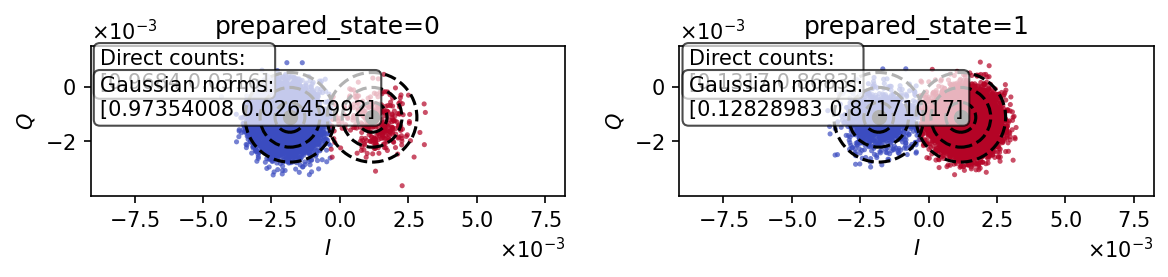

--- 2DHist ---


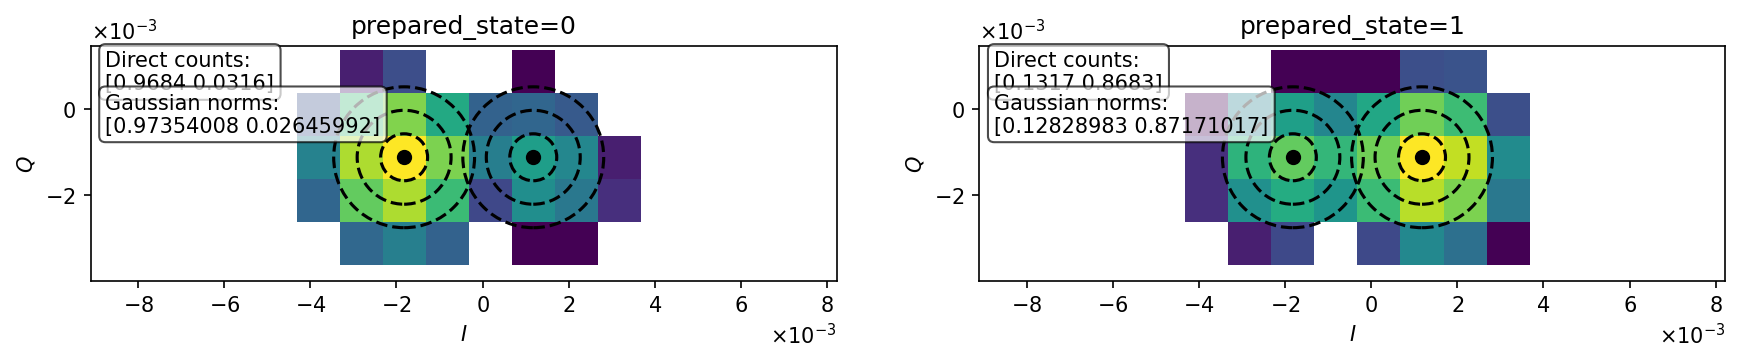

--- outliers ---


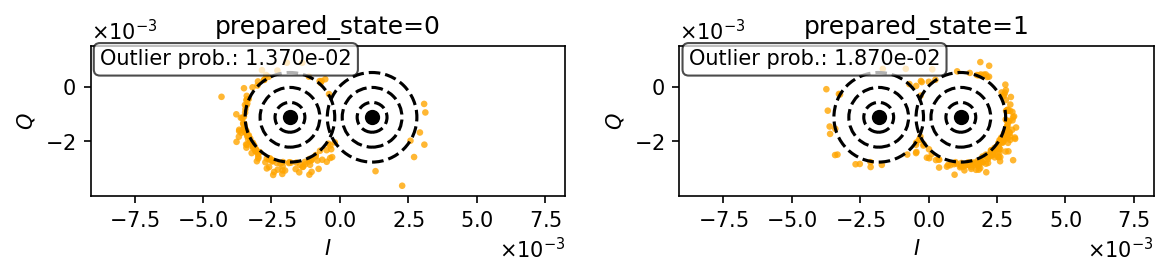

--- fit_residue ---


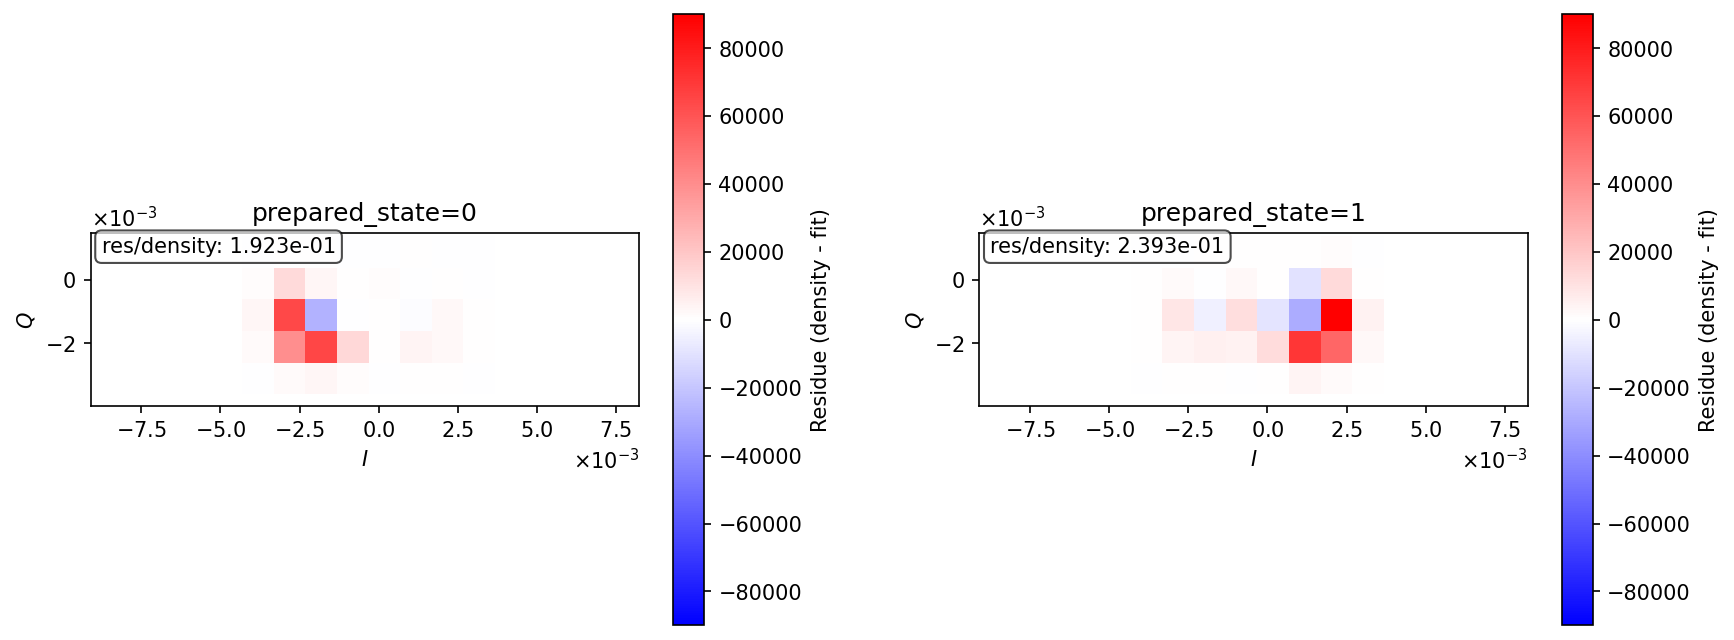

In [11]:
for name, fig in figs.items():
    print(f"--- {name} ---")
    display(fig)
    plt.close(fig)

## 5. Inspect Results

In [12]:
print("Trained GMM centers:\n", results["trained_paras"]["mean"])
print("\nDirect counts (per prepared state):\n", results["direct_counts"])
print("\nGaussian norms (per prepared state):\n", results["gaussian_norms"])
print("\nOutlier probability:", results["outlier_probability"])
print("\nNormalized fit residues:", results["norm_res"])

Trained GMM centers:
 [[-0.00182174 -0.00111865]
 [ 0.00117826 -0.00111865]]

Direct counts (per prepared state):
 [[0.9684 0.0316]
 [0.1317 0.8683]]

Gaussian norms (per prepared state):
 [[0.97354008 0.02645992]
 [0.12828983 0.87171017]]

Outlier probability: [0.0137 0.0187]

Normalized fit residues: [0.19234580263257373, 0.23928730200134612]
